# Ujicoba 4: google/gemma-4-E4B
## Dual A100 Benchmarking Pipeline

## Environment: DGX A100 80GB (Benchmarking Pipeline)


In [ ]:
import subprocess
# Periksa ketersediaan GPU dan Memory
!nvidia-smi


Tue Apr 21 10:22:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:07:00.0 Off |                    0 |
| N/A   30C    P0             54W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [1]:
# Hapus torchao yang jadi biang kerok error int1
!pip uninstall torchao -y

# Re-instal versi yang sinkron
!pip install --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps unsloth_zoo xformers==0.0.28.post3 trl peft accelerate bitsandbytes

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-evmmjmq5/unsloth_e4fce3551f72411a862f191ae18fcc12
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-evmmjmq5/unsloth_e4fce3551f72411a862f191ae18fcc12
  Resolved https://github.com/unslothai/unsloth.git to commit 41a6cc8692bd47ba0e4590b45bdf88d24b15ef33
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth: filename=unsloth-2026.4.7-py3-none-any.whl size=31568248 sha256=2600c1b4337f5b22f36cf9d3a4d50ce418e6daca602f17efb5e38d3be84b2297
  Stored in directory: /tmp/pip-ephem-wheel-cache-0vpdcq9o/wheels/60/3e/1f/e576c07051d90cf64b6a41434d87ccf4db33fafd5343bf5de0
Successfully built unsloth
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.

In [2]:
# Hapus torchcodec dan sentence-transformers yang narik dependensi bermasalah
!pip uninstall torchcodec sentence-transformers -y

# Instal ulang sentence-transformers tanpa dependensi audio/video jika memang butuh
!pip install sentence-transformers --no-deps

Found existing installation: torchcodec 0.10.0+cu128
Uninstalling torchcodec-0.10.0+cu128:
  Successfully uninstalled torchcodec-0.10.0+cu128
Found existing installation: sentence-transformers 5.4.0
Uninstalling sentence-transformers-5.4.0:
  Successfully uninstalled sentence-transformers-5.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 11.6 MB/s eta 0:00:00


In [4]:
import os
import torch
import sys
import shutil
from unittest.mock import MagicMock
import types


env_bin = "/home/riset/miniconda3/envs/unsloth_qwen3/bin"


def create_symlink(target, link_name):
    full_link = os.path.join(env_bin, link_name)
    full_target = os.path.join(env_bin, target)
    if not os.path.exists(full_link):
        try:
            os.symlink(full_target, full_link)
            print(f"✅ Symlink created: {link_name} -> {target}")
        except Exception as e:
            print(f"⚠️ Gagal bikin symlink {link_name}: {e}")

# Lakuin buat gcc dan g++
create_symlink("x86_64-conda-linux-gnu-gcc", "gcc")
create_symlink("x86_64-conda-linux-gnu-g++", "g++")

# 3. SET PATH & COMPILER ALIAS
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")
os.environ["CC"] = os.path.join(env_bin, "gcc")
os.environ["CXX"] = os.path.join(env_bin, "g++")

# Fix tambahan buat Triton
os.environ["TRITON_USE_CONTEXT_MANAGER"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["WANDB_NOTEBOOK_NAME"] = "uc4_gemma_cpt.ipynb"

import gc
import math
import time
import warnings
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import DataCollatorForLanguageModeling, Trainer, TrainingArguments
import wandb

warnings.filterwarnings("ignore")

# W&B Auth (Interactive fallback if not set)
if not os.environ.get("WANDB_API_KEY"):
    wandb.login()
else:
    wandb.login(key=os.environ.get("WANDB_API_KEY"))

if not os.environ.get("HF_TOKEN"):
    from huggingface_hub import login
    from getpass import getpass

    print("Masukan HF Token (Cek di huggingface.co/settings/tokens):")
    # Input ini rahasia, karakter tidak akan muncul saat diketik/dipaste
    hf_token = getpass()

    os.environ["HF_TOKEN"] = hf_token
    login(token=hf_token)
    print("✅ HF Login Success!")


# Cek apakah sekarang 'which gcc' udah ada isinya
gcc_check = os.popen('which gcc').read().strip()
if gcc_check:
    print(f"🚀 MANTAP! GCC ready at: {gcc_check}")
else:
    print("❌ Waduh, GCC masih belum nemu jalannya.")

def clear_vram():
    gc.collect()
    torch.cuda.empty_cache()


⚠️ Gagal bikin symlink gcc: [Errno 2] No such file or directory: '/home/riset/miniconda3/envs/unsloth_qwen3/bin/x86_64-conda-linux-gnu-gcc' -> '/home/riset/miniconda3/envs/unsloth_qwen3/bin/gcc'
⚠️ Gagal bikin symlink g++: [Errno 2] No such file or directory: '/home/riset/miniconda3/envs/unsloth_qwen3/bin/x86_64-conda-linux-gnu-g++' -> '/home/riset/miniconda3/envs/unsloth_qwen3/bin/g++'


wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find uc4_gemma_cpt.ipynb.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Masukan HF Token (Cek di huggingface.co/settings/tokens):
··········


HfHubHTTPError: Invalid user token. The token from HF_TOKEN environment variable is invalid. Note that HF_TOKEN takes precedence over `hf auth login`.

In [2]:
import os
import torch
import sys
import shutil
from unittest.mock import MagicMock
import types
import gc
import math
import time
import warnings
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import DataCollatorForLanguageModeling, Trainer, TrainingArguments
import wandb
def clear_vram():
    gc.collect()
    torch.cuda.empty_cache()


In [ ]:
# ========================
# CREDENTIALS & VRAM OPTIMIZATION
# ========================
import importlib

# --- 1. HARDCODE CREDENTIALS ---
# Masukkan token kamu langsung di sini
HF_TOKEN = "xxxx"
WANDB_KEY = "xxxx"

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["WANDB_API_KEY"] = WANDB_KEY

# --- 2. OPTIMASI VRAM ---
# Mengurangi fragmentasi memori, krusial untuk T4 di Colab
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def clear_vram():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    gc.collect()

# --- 3. VALIDASI & LOGIN ---
if HF_TOKEN == "ISI_TOKEN_HUGGINGFACE_DISINI" or HF_TOKEN == "":
    print("❌ Token HuggingFace belum diisi!")
else:
    print(f"✅ Akun Liza Aktif!")

    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9

        print(f"✅ GPU Terdeteksi: {gpu_name}")
        print(f"✅ Total VRAM: {vram_total:.2f} GB")

        if WANDB_KEY != "ISI_API_KEY_WANDB_DISINI" and WANDB_KEY != "":
            wandb.login(key=WANDB_KEY, relogin=True)
            print("WandB Login Berhasil!")
        else:
            print("⚠️ Warning: API Key WandB belum diisi.")
    else:
        print("⚠️ Warning: GPU tidak terdeteksi. Pastikan Runtime Type adalah T4 GPU.")

# Bersihkan sisa memori sebelum masuk ke tahap loading model
clear_vram()

✅ Akun Liza Aktif!
✅ GPU Terdeteksi: NVIDIA A100-SXM4-40GB
✅ Total VRAM: 42.41 GB


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: halizaapalwan (halizaapalwan-sepuluh-nopember-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB Login Berhasil!


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================
# CONFIGURATION
# ============================================
MODEL_NAME = "google/gemma-4-E4B"
DATASET_PATH = "/content/drive/MyDrive/CPT/88k_news_cleaned.jsonl"
WANDB_PROJECT = "tim1-dfk-cpt-comparison"
WANDB_RUN = "uc4-gemma-4-E4B-cpt"

MAX_ROWS = 44000
MAX_SEQ_LENGTH = 2048

# Training Params
EPOCHS = 3
PER_DEVICE_BATCH = 8
GRAD_ACCUM_STEPS = 8

# LoRA Params
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

# Native setup for A100 (Ampere)
compute_dtype = torch.bfloat16

clear_vram()


## 1. Model Loading (Unsloth)


In [5]:
from unsloth import FastLanguageModel

print("Loading model via Unsloth...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = compute_dtype,
    load_in_4bit = True,
)
tokenizer.padding_side = "right"

vram_after_load = torch.cuda.memory_reserved() / 1e9
print(f"[VRAM] After Model Load: {vram_after_load:.2f} GB")

model = FastLanguageModel.get_peft_model(
    model,
    r = LORA_R,
    target_modules = TARGET_MODULES,
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

model.print_trainable_parameters()
vram_after_lora = torch.cuda.memory_reserved() / 1e9
print(f"[VRAM] After LoRA Setup: {vram_after_lora:.2f} GB")
clear_vram()


/tmp/ipykernel_11101/1947715065.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading model via Unsloth...
==((====))==  Unsloth 2026.4.7: Fast Gemma4 patching. Transformers: 5.6.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

[VRAM] After Model Load: 11.62 GB


[transformers] Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


trainable params: 40,583,168 || all params: 7,981,684,000 || trainable%: 0.5085
[VRAM] After LoRA Setup: 11.78 GB


In [ ]:
!pip install --upgrade transformers


## 2. Dataset Handling & EDA


Loading dataset from /content/drive/MyDrive/CPT/88k_news_cleaned.jsonl...
Total Rows Selected: 44000


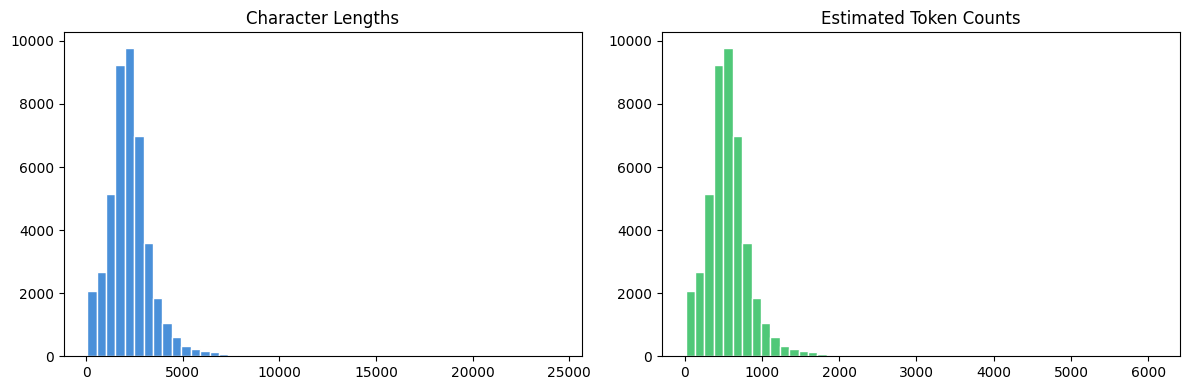

Tokenizing dataset...


Tokenizing...:   0%|          | 0/39600 [00:00<?, ? examples/s]

Tokenizing...:   0%|          | 0/4400 [00:00<?, ? examples/s]

Packing dataset (group_texts)...


Packing to 2048:   0%|          | 0/39600 [00:00<?, ? examples/s]

Packing to 2048:   0%|          | 0/4400 [00:00<?, ? examples/s]

Packed Train Blocks Ready: 10310


In [6]:
print(f"Loading dataset from {DATASET_PATH}...")
if os.path.exists(DATASET_PATH):
    raw_dataset = load_dataset("json", data_files=DATASET_PATH, split="train")
else:
    # Dummy fallback if file doesn't exist yet
    print("[WARNING] File not found! Using dummy data for setup validity.")
    raw_dataset = load_dataset("json", data_files={"train": [{"text": "Dataset dummy eksperimen DFK. " * 50}] * 20000}, split="train")

# Shuffle with seed 42 then select top 10000
if MAX_ROWS is not None:
    raw_dataset = raw_dataset.shuffle(seed=42).select(range(min(MAX_ROWS, len(raw_dataset))))
else:
    raw_dataset = raw_dataset.shuffle(seed=42)
print(f"Total Rows Selected: {len(raw_dataset)}")

# EDA (Matplotlib)
texts = raw_dataset["text"]
char_lens = [len(t) for t in texts]
token_lens_est = [c / 4 for c in char_lens] # estimated tokens

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_lens, bins=50, color="#4A90D9", edgecolor="white")
axes[0].set_title("Character Lengths")
axes[1].hist(token_lens_est, bins=50, color="#50C878", edgecolor="white")
axes[1].set_title("Estimated Token Counts")
plt.tight_layout()
plt.show()

split_dataset = raw_dataset.train_test_split(test_size=0.1, seed=42)

print("Tokenizing dataset...")
def tokenize_fn(examples):
    # ✅ Tambahkan .tokenizer di pemanggilan eos_token dan saat me-return
    # texts = [str(text) + tokenizer.tokenizer.eos_token for text in examples["text"]]
    texts = [tokenizer.tokenizer.bos_token + str(text) + tokenizer.tokenizer.eos_token for text in examples["text"]]
    return tokenizer.tokenizer(texts)

tokenized_datasets = split_dataset.map(
    tokenize_fn,
    batched=True,
    remove_columns=split_dataset["train"].column_names,
    desc="Tokenizing..."
)

print("Packing dataset (group_texts)...")
def group_texts(examples):
    # Gabungkan semua token
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples["input_ids"])
    # Buang sisa ekor yang tidak pas
    total_length = (total_length // MAX_SEQ_LENGTH) * MAX_SEQ_LENGTH
    # Pecah jadi gerbong
    result = {
        k: [t[i : i + MAX_SEQ_LENGTH] for i in range(0, total_length, MAX_SEQ_LENGTH)]
        for k, t in concatenated_examples.items()
    }
    return result

packed_datasets = tokenized_datasets.map(
    group_texts,
    batched=True,
    desc=f"Packing to {MAX_SEQ_LENGTH}"
)

train_dataset = packed_datasets["train"]
eval_dataset = packed_datasets["test"]
print(f"Packed Train Blocks Ready: {len(train_dataset)}")


## 3. Baseline Evaluation (Wiki-ID Check)


In [7]:
# Reference general domain strings
print("Mulai")

wiki_texts = [
    "Indonesia adalah negara kepulauan terbesar di dunia yang terletak di Asia Tenggara. Negara ini memiliki keanekaragaman budaya, bahasa, dan agama yang sangat kaya.",
    "Gunung Bromo adalah salah satu gunung berapi aktif yang terletak di Jawa Timur, Indonesia. Gunung ini memiliki ketinggian 2.329 meter di atas permukaan laut.",
    "Bahasa Indonesia adalah bahasa resmi Republik Indonesia dan bahasa persatuan bangsa Indonesia yang diresmikan setelah Proklamasi Kemerdekaan Indonesia pada tahun 1945.",
    "Borobudur adalah candi Buddha terbesar di dunia yang terletak di Magelang, Jawa Tengah. Candi ini dibangun pada abad ke-8 oleh wangsa Sailendra.",
    "Komodo adalah spesies kadal terbesar di dunia yang hanya ditemukan di Kepulauan Komodo, Nusa Tenggara Timur, Indonesia.",
    "Ekonomi Indonesia adalah ekonomi terbesar di Asia Tenggara dan termasuk dalam kelompok G20.",
    "Wayang kulit adalah seni pertunjukan tradisional Indonesia yang menggunakan boneka dari kulit kerbau atau sapi.",
    "Pancasila adalah dasar negara dan ideologi bangsa Indonesia yang terdiri dari lima sila."
]

wiki_encodings = tokenizer.tokenizer(
    [tokenizer.tokenizer.bos_token + t + tokenizer.tokenizer.eos_token for t in wiki_texts],
    truncation=True, padding=False, max_length=MAX_SEQ_LENGTH, return_tensors=None,
)
from datasets import Dataset as HFDataset
wiki_dataset = HFDataset.from_dict({
    "input_ids": wiki_encodings["input_ids"],
    "attention_mask": wiki_encodings["attention_mask"]
})

eval_args = TrainingArguments(
    output_dir="./temp_eval",
    per_device_eval_batch_size=1,
    bf16=True,
    fp16=False,
    prediction_loss_only=True,
    report_to="none",
    disable_tqdm=True
)

baseline_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=wiki_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer.tokenizer, mlm=False) # ✅ Tambahkan .tokenizer di sini
)

print("Evaluating Baseline Wiki-ID (Before Training)...")
baseline_eval = baseline_trainer.evaluate()
baseline_general_ppl = math.exp(baseline_eval["eval_loss"])
print(f"Baseline General PPL: {baseline_general_ppl:.4f}")

del baseline_trainer
clear_vram()


Mulai
Evaluating Baseline Wiki-ID (Before Training)...
{'eval_loss': '2.049', 'eval_model_preparation_time': '0.0555', 'eval_runtime': '8.992', 'eval_samples_per_second': '0.89', 'eval_steps_per_second': '0.89', 'epoch': 0}
Baseline General PPL: 7.7581


## 4. Benchmarking Training


In [8]:
# NO PERSISTENCE: save_strategy set to "no" purely for efficiency benchmark
training_args = TrainingArguments(
    output_dir=f"./outputs/{WANDB_RUN}",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=100,
    weight_decay=0.01,
    max_grad_norm=1.0,
    bf16=True,
    fp16=False,
    # logging_steps=5,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    optim="adamw_8bit",
    gradient_checkpointing=True,
    report_to="wandb",
    run_name=WANDB_RUN,
    prediction_loss_only=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer.tokenizer, mlm=False), # ✅ Tambahkan .tokenizer di sini
)

print("Starting Benchmarking Training...")
torch.cuda.reset_peak_memory_stats()
start_time = time.time()

train_result = trainer.train(resume_from_checkpoint = False)

end_time = time.time()
runtime = end_time - start_time
peak_vram = torch.cuda.max_memory_reserved() / 1e9
# tokens_per_sec = train_result.metrics.get('train_samples_per_second', 0) * MAX_SEQ_LENGTH
tokens_per_sec = train_result.metrics.get('train_tokens_per_second', 0)

print(f"\n[BENCHMARK] Total Training Time: {runtime:.2f} seconds")
print(f"[BENCHMARK] Peak Reserved VRAM: {peak_vram:.2f} GB")
print(f"[BENCHMARK] Throughput: {tokens_per_sec:.2f} tokens/sec")

clear_vram()


Starting Benchmarking Training...


[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,310 | Num Epochs = 3 | Total steps = 486
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 8 x 1) = 64
 "-____-"     Trainable parameters = 40,583,168 of 7,981,684,000 (0.51% trained)


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/
[transformers] Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
200,1.791267,1.796729
400,1.771001,1.778571
486,1.757668,1.779024


[transformers] Unsloth: Restored added_tokens_decoder metadata in ./outputs/uc4-gemma-4-E4B-cpt/checkpoint-200/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in ./outputs/uc4-gemma-4-E4B-cpt/checkpoint-400/tokenizer_config.json.
[transformers] Unsloth: Restored added_tokens_decoder metadata in ./outputs/uc4-gemma-4-E4B-cpt/checkpoint-486/tokenizer_config.json.



[BENCHMARK] Total Training Time: 21350.12 seconds
[BENCHMARK] Peak Reserved VRAM: 32.57 GB
[BENCHMARK] Throughput: 0.00 tokens/sec


In [ ]:
# print("\nSaving LoRA Adapter and Tokenizer...")
# trainer.model.save_pretrained("./lora_dfk_uc4_gemma")
# tokenizer.save_pretrained("./lora_dfk_uc4_gemma")
# print("Save complete!")


## 5. Post-Eval & Qualitative Checks


In [9]:
from datasets import Dataset as HFDataset

print("\nRe-evaluating Wiki-ID Domain...")
post_trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=wiki_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer.tokenizer, mlm=False) # ✅ TAMBAHKAN .tokenizer
)
post_eval = post_trainer.evaluate()
final_general_ppl = math.exp(post_eval["eval_loss"])

wiki_degradation = ((final_general_ppl - baseline_general_ppl) / baseline_general_ppl) * 100

print(f"Final General PPL: {final_general_ppl:.4f}")
print(f"Degradation %: {wiki_degradation:.2f}%")

del post_trainer
clear_vram()

# Qualitative Generation
import torch
model.config.use_cache = True
prompts = [
    "Disinformasi di Indonesia terutama menyebar lewat",
    "Narasi ujaran kebencian di masa pemilu rentan memecah",
    "Berita palsu seringkali mengandung judul yang clickbait seperti"
]

print("\n[GENERATION SAMPLES]")
for p in prompts:
    # Tambahkan .tokenizer di inputs, pad_token_id, dan decode
    inputs = tokenizer.tokenizer(p, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=50, temperature=0.7, top_p=0.9, do_sample=True, pad_token_id=tokenizer.tokenizer.eos_token_id, eos_token_id=tokenizer.tokenizer.eos_token_id)
    print(f"Prompt: {p}\nOutput: {tokenizer.tokenizer.decode(out[0], skip_special_tokens=True)}\n")

model.config.use_cache = False
clear_vram()



Re-evaluating Wiki-ID Domain...
{'eval_loss': '1.677', 'eval_model_preparation_time': '0.06', 'eval_runtime': '2.012', 'eval_samples_per_second': '3.977', 'eval_steps_per_second': '3.977', 'epoch': 0}
Final General PPL: 5.3472
Degradation %: -31.08%

[GENERATION SAMPLES]
Prompt: Disinformasi di Indonesia terutama menyebar lewat
Output: Disinformasi di Indonesia terutama menyebar lewat media sosial. "Jadi, kita harus berhati-hati, jangan sampai kita menjadi korban dari informasi yang tidak benar," kata dia. Dia mengatakan, pihaknya akan terus berupaya untuk mengedukasi masyarakat agar tidak mudah percaya dengan informasi yang belum

Prompt: Narasi ujaran kebencian di masa pemilu rentan memecah
Output: Narasi ujaran kebencian di masa pemilu rentan memecah belah persatuan bangsa. "Jangan sampai kita terpecah belah karena perbedaan pilihan politik," kata dia.

Prompt: Berita palsu seringkali mengandung judul yang clickbait seperti
Output: Berita palsu seringkali mengandung judul yang clic

In [10]:

print("\nRunning Final Evaluation...")
final_eval = trainer.evaluate()
final_loss = final_eval["eval_loss"]

# Hitung PPL: e^loss
final_ppl = math.exp(final_loss)

print(f"Final Eval Loss: {final_loss:.4f}")
print(f"Final Validation PPL: {final_ppl:.4f}")


Running Final Evaluation...


Training Loss,Validation Loss,Step
1.757668,1.779024,486


Final Eval Loss: 1.7790
Final Validation PPL: 5.9241


## 6. Finish & WandB Logistics


In [11]:
wandb.log({
    "Benchmark/Peak_VRAM_GB": peak_vram,
    "Benchmark/Runtime_Secs": runtime,
    "Benchmark/Tokens_Per_Sec": tokens_per_sec,
    "Eval/Baseline_Wiki_PPL": baseline_general_ppl,
    "Eval/Final_Wiki_PPL": final_general_ppl,
    "Eval/Wiki_Degradation_Pct": wiki_degradation,
    "Eval/Final_PPL": final_ppl,
})
wandb.finish()
print("Experiment Logs synchronized to W&B successfully!")


Benchmark/Peak_VRAM_GB,▁
Benchmark/Runtime_Secs,▁
Benchmark/Tokens_Per_Sec,▁
Eval/Baseline_Wiki_PPL,▁
Eval/Final_PPL,▁
Eval/Final_Wiki_PPL,▁
Eval/Wiki_Degradation_Pct,▁
eval/loss,█▁▁▁
eval/runtime,▇█▇▁
eval/samples_per_second,▂▁▂█
+6,...


Experiment Logs synchronized to W&B successfully!
